In [1]:
import torch
from ptflops import get_model_complexity_info

from lite_org import LITE
from inception import Classifier_INCEPTION

import pandas as pd
import numpy as np
import os

from utils import load_data, preprocess_data
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

In [2]:
import torch.nn as nn
import time


criterion_CE = nn.CrossEntropyLoss()

def test(model, valloader):
    print('From the test set evaluation')
    model.eval()
    test_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(valloader):
            
            inputs, targets = inputs.cuda(), targets.cuda()

            outputs, _= model(inputs.float())
            loss = criterion_CE(outputs, targets)
            
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += predicted.eq(targets.data).cpu().sum().float().item()

        print('Test Loss: %.3f | Test Acc: %.3f%% (%d/%d)' % (test_loss / (batch_idx + 1), 100. * correct / total, correct, total))
        return test_loss / (batch_idx + 1), 100. * correct / total


In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

columns=['Dataset', 'base_macs', 'base_params', 'prune_macs', 'prune_params', 'prune_params_manual' ]
hmm = [9409, 3804, 3952, 2561, 5296]
tmp_df_5296 = pd.DataFrame(columns=columns)
seed = 5296

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    co_params = 0
    
    model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    base_params = sum(p.numel() for p in model_base.parameters())
    
    
    with torch.no_grad():
        macs, params = get_model_complexity_info(model_base, (1, length_TS), as_strings=False, 
                                                print_per_layer_stat=False, verbose=False)
        
    rows.append(macs)
    rows.append(params)
            
    model_base.cuda()
    model_base.eval()


    model_pruned = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    co_params = sum(p.numel() for p in model_pruned.parameters())

    with torch.no_grad():
        macs, params = get_model_complexity_info(model_pruned, (1, length_TS), as_strings=False, 
                                                print_per_layer_stat=False, verbose=False)
        
        rows.append(macs)
        rows.append(params)
        
        rows.append(co_params)


        
    tmp_df_5296 = pd.concat([tmp_df_5296, pd.DataFrame([rows], columns=columns)])

In [ ]:

dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# dataset_names = ['EthanolLevel']
# dataset_names = ['BeetleFly']
columns=['Dataset', 'base_inf_time', 'dsp_inf_time']
tmp_df_5296 = pd.DataFrame(columns=columns)
hmm = [9409, 3804, 3952, 2561, 5296]

seed = 5296

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    co_params = 0
    
    model_base_lite = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_base_lite.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))    
    model_base_lite.cuda()
    model_base_lite.eval()
    
    
    start_time = time.time()
    test(model_base_lite, testloader)
    end_time = time.time()
    inf_time = end_time - start_time
    rows.append(inf_time)

    model_pruned = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    model_pruned.cuda()
    model_pruned.eval()

    start_time = time.time()
    test(model_pruned, testloader)
    end_time = time.time()
    inf_time = end_time - start_time
    rows.append(inf_time)
        
    tmp_df_5296 = pd.concat([tmp_df_5296, pd.DataFrame([rows], columns=columns)])

In [14]:
tmp_df_5296

,Dataset,base_inf_time,dsp_inf_time
0,ACSF1,0.190684,0.005174
0,Adiac,0.015525,0.007721
0,AllGestureWiimoteX,0.014850,0.010726
0,AllGestureWiimoteY,0.007881,0.010703
0,AllGestureWiimoteZ,0.007840,0.010181
...,...,...,...
0,Crop,0.171300,0.169352
0,ElectricDevices,0.082355,0.077272
0,FordA,0.019082,0.016691
0,FordB,0.015087,0.013703


In [ ]:
hmm = [9409, 3804, 3952, 2561, 5296]

sum_df = tmp_df_9409[['base_inf_time',	'dsp_inf_time']] + \
            tmp_df_3804[['base_inf_time',	'dsp_inf_time']] + \
                tmp_df_3952[['base_inf_time',	'dsp_inf_time']] + \
                    tmp_df_2561[['base_inf_time',	'dsp_inf_time']] + \
                        tmp_df_5296[['base_inf_time',	'dsp_inf_time']]
                        
                    
                



In [11]:
sum_df

,base_inf_time,dsp_inf_time
0,0.201350,0.025261
0,0.034045,0.037019
0,0.047602,0.053650
0,0.041139,0.052272
0,0.040035,0.049215
...,...,...
0,0.824156,0.812795
0,0.388988,0.385767
0,0.085028,0.082033
0,0.054376,0.059382


In [ ]:
sum_df['base_inf_time'].mean()

np.float64(0.062455786392092705)

In [ ]:
sum_df['dsp_inf_time'].mean()


np.float64(0.06531739607453346)

In [221]:
import torch.nn as nn
import time


criterion_CE = nn.CrossEntropyLoss()

def test_inc(model, valloader):
    print('From the test set evaluation')
    model.eval()
    test_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(valloader):
            
            inputs, targets = inputs.cuda(), targets.cuda()

            outputs = model(inputs.float())
            loss = criterion_CE(outputs, targets)
            
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += predicted.eq(targets.data).cpu().sum().float().item()

        print('Test Loss: %.3f | Test Acc: %.3f%% (%d/%d)' % (test_loss / (batch_idx + 1), 100. * correct / total, correct, total))
        return test_loss / (batch_idx + 1), 100. * correct / total


In [ ]:

dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# dataset_names = ['EthanolLevel']
# dataset_names = ['BeetleFly']
columns=['Dataset', 'base_inf_time', 'dsp_inf_time']
tmp_df_5296 = pd.DataFrame(columns=columns)
hmm = [9409, 3804, 3952, 2561, 5296]

seed = 5296

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    co_params = 0
    
    input_shape = xtrain.shape[1:]
    nb_classes = len(np.unique(ytrain))

    
    model_base_inc = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32]]),)        
    
    model_base_inc.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
    model_base_inc.cuda()
    model_base_inc.eval()
    
    
    start_time = time.time()
    test_inc(model_base_inc, testloader)
    end_time = time.time()
    inf_time = end_time - start_time
    rows.append(inf_time)

    model_pruned_inc = torch.load(os.getcwd() + f'/results_inception/scratch_training_1e-5_weights_1_1_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    model_pruned_inc.cuda()
    model_pruned_inc.eval()

    start_time = time.time()
    test_inc(model_pruned_inc, testloader)
    end_time = time.time()
    inf_time = end_time - start_time
    rows.append(inf_time)
        
    tmp_df_5296 = pd.concat([tmp_df_5296, pd.DataFrame([rows], columns=columns)])

In [ ]:
hmm = [9409, 3804, 3952, 2561, 5296]

tmp_df_5296

,Dataset,base_inf_time,dsp_inf_time
0,ACSF1,0.010505,0.016868
0,Adiac,0.008835,0.024649
0,AllGestureWiimoteX,0.024748,0.027362
0,AllGestureWiimoteY,0.025144,0.026700
0,AllGestureWiimoteZ,0.024707,0.024379
...,...,...,...
0,Crop,0.240306,0.265037
0,ElectricDevices,0.137268,0.148945
0,FordA,0.047004,0.029383
0,FordB,0.029294,0.021991


In [24]:
tmp_df_9409[1:2]

,Dataset,base_macs,base_params,prune_macs,prune_params,prune_params_manual
0,Adiac,1885125,11035,1368741,8179,8617


In [25]:
sum_df = tmp_df_9409[['base_macs', 'base_params', 'prune_macs', 'prune_params', 'prune_params_manual']] + \
            tmp_df_3804[['base_macs', 'base_params', 'prune_macs', 'prune_params', 'prune_params_manual']] + \
                tmp_df_3952[['base_macs', 'base_params', 'prune_macs', 'prune_params', 'prune_params_manual']] + \
                    tmp_df_2561[['base_macs', 'base_params', 'prune_macs', 'prune_params', 'prune_params_manual']] + \
                        tmp_df_5296[['base_macs', 'base_params', 'prune_macs', 'prune_params', 'prune_params_manual']] 
                        
                    
                    
                

In [26]:
sum_df

,base_macs,base_params,prune_macs,prune_params,prune_params_manual
0,78140850,50720,37805310,23673,25863
0,9425625,55175,6984329,41664,43854
0,26761650,50720,19811570,36787,38977
0,26761650,50720,16077500,29463,31653
0,26761650,50720,13829630,25151,27341
...,...,...,...,...,...
0,2465880,53030,2462844,52966,55156
0,5139075,50225,4568854,44381,46571
0,26760330,49400,12734062,22232,24422
0,26760330,49400,13698046,24114,26304


In [29]:
sum_df['pruning_ratio'] = 1 - sum_df['prune_params'] / sum_df['base_params']

In [ ]:
# sum_df.to_csv('sum_df_lite_5_runs.csv', index=False)

In [30]:
sum_df['pruning_ratio'].mean()

np.float64(0.5820482338720119)

In [237]:
sum_df['base_inf_time'].mean()


np.float64(0.17968209646642208)

In [238]:
sum_df['dsp_inf_time'].mean()


np.float64(0.1511356495320797)

In [ ]:
def model_size_in_MB(model):
    total_bytes = 0
    for param in model.parameters():
        total_bytes += param.numel() * torch.finfo(param.dtype).bits / 8  # bits to bytes
    return total_bytes / (1024 * 1024)  # Bytes to Kilobytes

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# dataset_names = ['EthanolLevel']
# dataset_names = ['BeetleFly']
columns=['Dataset', 'base_l_macs', 'base_l_params', 'base_l_params_manual', 'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size']
tmp_df_ = pd.DataFrame(columns=columns)
hmm = [9409, 3804, 3952, 2561, 5296]

seed = 3804

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    co_params = 0
    
    model_base_lite = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_base_lite.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    base_params = sum(p.numel() for p in model_base_lite.parameters())
    
    model_base_lite.cuda()
    model_base_lite.eval()
     

    with torch.no_grad():
        macs, params = get_model_complexity_info(model_base_lite, (1, length_TS), as_strings=False, 
                                                print_per_layer_stat=False, verbose=False)
        
        rows.append(macs)
        rows.append(params)
        rows.append(base_params)
        base_model_size = model_size_in_MB(model_base_lite)
        rows.append(base_model_size)
    

    model_pruned = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    # co_params_0 = sum(p.numel() for p in model_pruned.parameters())
    co_params = sum(p.numel() for p in model_pruned.parameters())

    with torch.no_grad():
        macs, params = get_model_complexity_info(model_pruned, (1, length_TS), as_strings=False, 
                                                print_per_layer_stat=False, verbose=False)
        
        rows.append(macs)
        rows.append(params)
        
        # rows.append(co_params_0)
        rows.append(co_params)
        dsp_model_size = model_size_in_MB(model_pruned)
        rows.append(dsp_model_size)

        
    tmp_df_5296 = pd.concat([tmp_df_5296, pd.DataFrame([rows], columns=columns)])

In [ ]:
# [9409, 3804, 3952, 2561, 5296]
tmp_df_9409[1:2]

,Dataset,base_l_macs,base_l_params,base_l_params_manual,base_model_size,pruned_l_macs,pruned_l_params,pruned_l_params_manual,dsp_model_size
0,Adiac,1885125,11035,11473,0.043766,1368741,8179,8617,0.032871


In [ ]:
tmp_df_3804[1:2]

,Dataset,base_l_macs,base_l_params,base_l_params_manual,base_model_size,pruned_l_macs,pruned_l_params,pruned_l_params_manual,dsp_model_size
0,Adiac,1885125,11035,11473,0.043766,1325797,7937,8375,0.031948


In [ ]:
tmp_df_3952[1:2]


,Dataset,base_l_macs,base_l_params,base_l_params_manual,base_model_size,pruned_l_macs,pruned_l_params,pruned_l_params_manual,dsp_model_size
0,Adiac,1885125,11035,11473,0.043766,1325797,7937,8375,0.031948


In [ ]:
tmp_df_2561[1:2]


,Dataset,base_l_macs,base_l_params,base_l_params_manual,base_model_size,pruned_l_macs,pruned_l_params,pruned_l_params_manual,dsp_model_size
0,Adiac,1885125,11035,11473,0.043766,1325797,7937,8375,0.031948


In [ ]:
tmp_df_5296[1:2]


,Dataset,base_l_macs,base_l_params,base_l_params_manual,base_model_size,pruned_l_macs,pruned_l_params,pruned_l_params_manual,dsp_model_size
0,Adiac,1885125,11035,11473,0.043766,1325797,7937,8375,0.031948


In [ ]:
sum_df = tmp_df_9409[['base_l_macs',	'base_l_params', 'base_l_params_manual', 'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size']] + \
    tmp_df_3804[['base_l_macs',	'base_l_params', 'base_l_params_manual',  'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size'] ] + \
        tmp_df_3952[['base_l_macs',	'base_l_params', 'base_l_params_manual',  'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size'] ] + \
            tmp_df_2561[['base_l_macs',	'base_l_params', 'base_l_params_manual',  'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size'] ] + \
                tmp_df_5296[['base_l_macs',	'base_l_params', 'base_l_params_manual',  'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size'] ]                         

In [ ]:
avg_df = sum_df / 5

In [ ]:
avg_df

,base_l_macs,base_l_params,base_l_params_manual,pruned_l_macs,pruned_l_params,pruned_l_params_manual
0,15628170.0,10144.0,10582.0,7561062.0,4734.6,5172.6
0,1885125.0,11035.0,11473.0,1396865.8,8332.8,8770.8
0,5352330.0,10144.0,10582.0,3962314.0,7357.4,7795.4
0,5352330.0,10144.0,10582.0,3215500.0,5892.6,6330.6
0,5352330.0,10144.0,10582.0,2765926.0,5030.2,5468.2
...,...,...,...,...,...,...
0,493176.0,10606.0,11044.0,492568.8,10593.2,11031.2
0,1027815.0,10045.0,10483.0,913770.8,8876.2,9314.2
0,5352066.0,9880.0,10318.0,2546812.4,4446.4,4884.4
0,5352066.0,9880.0,10318.0,2739609.2,4822.8,5260.8


In [ ]:
# avg_df['prune_ratio'] = 1 - avg_df['pruned_l_params'] /  avg_df['base_l_params'] 
avg_df['prune_ratio'] = 1 - avg_df['pruned_l_params_manual'] /  avg_df['base_l_params_manual'] 

In [ ]:
avg_df['prune_ratio'].mean()

np.float64(0.5576883072424286)

In [ ]:
sum_df['base_l_params'].mean()

np.float64(50511.171875)

In [ ]:
sum_df['pruned_l_params'].mean()


np.float64(21298.96875)

In [ ]:
1 - 4259.79375 / 10102.234375

0.5783315262867281

In [ ]:
sum_df['base_flops'] = 2 * sum_df['base_l_macs']
sum_df['pruned_flops'] = 2 * sum_df['pruned_l_macs']

In [ ]:
sum_df['base_flops'].mean() / 1000000

np.float64(57.21994359375)

In [ ]:
sum_df['pruned_flops'].mean()/1000000


np.float64(22.750674234375)

In [ ]:
sum_df['base_model_size'].mean()

np.float64(0.20103901624679565)

In [ ]:
sum_df['dsp_model_size'].mean()


np.float64(0.09006693959236145)

In [ ]:
# tmp_df['flop_ratio_diff'] = (tmp_df['base_flops'] - tmp_df['pruned_flops']) / tmp_df['base_flops']

In [ ]:
# tmp_df.sort_values(['flop_ratio_diff'], ascending=False)

,Dataset,base_l_macs,base_l_params,base_l_params_manual,pruned_l_macs,pruned_l_params,pruned_l_params_manual,base_flops,pruned_flops,flop_ratio)diff,flop_ratio_diff
0,EthanolLevel,18742836,9946,10384,1861321,553,991,37485672,3722642,0.900692,0.900692
0,HandOutlines,28997202,9880,10318,4150192,996,1434,57994404,8300384,0.856876,0.856876
0,SonyAIBORobotSurface2,695826,9880,10318,103630,1046,1484,1391652,207260,0.851069,0.851069
0,StarLightCurves,10960995,9913,10351,1760277,1172,1610,21921990,3520554,0.839405,0.839405
0,FreezerSmallTrain,3221970,9880,10318,519239,1175,1613,6443940,1038478,0.838844,0.838844
...,...,...,...,...,...,...,...,...,...,...,...
0,UWaveGestureLibraryX,3372024,10078,10516,2682684,7876,8314,6744048,5365368,0.204429,0.204429
0,MiddlePhalanxTW,856518,10012,10450,753602,8740,9178,1713036,1507204,0.120156,0.120156
0,ElectricDevices,1027815,10045,10483,953312,9284,9722,2055630,1906624,0.072487,0.072487
0,MelbournePedestrian,257226,10144,10582,245722,9624,10062,514452,491444,0.044723,0.044723


In [ ]:
tmp_df['base_flops'] = 2 * tmp_df['base_l_macs']
tmp_df['pruned_flops'] = 2 * tmp_df['pruned_l_macs']


NameError: name 'tmp_df' is not defined

In [ ]:
tmp_df

,Dataset,base_l_macs,base_l_params,base_l_params_manual,pruned_l_macs,pruned_l_params,pruned_l_params_manual,base_flops,pruned_flops
0,EthanolLevel,18742836,9946,10384,1861321,553,991,37485672,3722642


In [ ]:
tmp_df[tmp_df['pruned_flops'] == tmp_df['pruned_flops'].min()]

,Dataset,base_l_macs,base_l_params,base_l_params_manual,pruned_l_macs,pruned_l_params,pruned_l_params_manual,base_flops,pruned_flops
0,SmoothSubspace,160659,9913,10351,67044,3820,4258,321318,134088


## Inception  results

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# dataset_names = ['EthanolLevel']
# columns=['Dataset', 'base_l_macs', 'base_l_params', 'base_l_params_manual', 'base_model_size', 'pruned_l_macs', 'pruned_l_params', 'pruned_l_params_manual', 'dsp_model_size']
columns=['Dataset', 'base_inc_macs', 'base_inc_params', 'base_inc_params_manual', 'base_model_size', 'pruned_inc_macs', 'pruned_inc_params', 'pruned_inc_params_manual', 'dsp_model_size']
tmp_df_inc_9409 = pd.DataFrame(columns=columns)
hmm = [9409, 3804, 3952, 2561, 5296]
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    co_params = 0
    
    input_shape = xtrain.shape[1:]
    nb_classes = len(np.unique(ytrain))


    model_base_inc = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32]]),)        
    
    model_base_inc.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
    base_params = sum(p.numel() for p in model_base_inc.parameters())
    
    model_base_inc.cuda()
    model_base_inc.eval()
     

    with torch.no_grad():
        macs, params = get_model_complexity_info(model_base_inc, (1, length_TS), as_strings=False, 
                                                print_per_layer_stat=False, verbose=False)
        
        rows.append(macs)
        rows.append(params)
        rows.append(base_params)
        base_model_size = model_size_in_MB(model_base_inc)
        rows.append(base_model_size)

    

    model_pruned_inc = torch.load(os.getcwd() + f'/results_inception/scratch_training_1e-5_weights_1_1_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
    co_params = sum(p.numel() for p in model_pruned_inc.parameters())

    with torch.no_grad():
        macs, params = get_model_complexity_info(model_pruned_inc, (1, length_TS), as_strings=False, 
                                                print_per_layer_stat=False, verbose=False)
        
        rows.append(macs)
        rows.append(params)        
        rows.append(co_params)
        dsp_model_size = model_size_in_MB(model_pruned_inc)
        rows.append(dsp_model_size)



        
    tmp_df_inc_9409 = pd.concat([tmp_df_inc_9409, pd.DataFrame([rows], columns=columns)])

In [ ]:
tmp_df_inc_9409

,Dataset,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size
0,ACSF1,618717170,421482,421482,1.607826,117990210,79975,79975,0.305080
0,Adiac,74589701,424965,424965,1.621113,40433254,230812,230812,0.880478
0,AllGestureWiimoteX,211890290,421482,421482,1.607826,54379630,107975,107975,0.411892
0,AllGestureWiimoteY,211890290,421482,421482,1.607826,69993640,139087,139087,0.530575
0,AllGestureWiimoteZ,211890290,421482,421482,1.607826,50309140,99832,99832,0.380829
...,...,...,...,...,...,...,...,...,...
0,Crop,19496884,423288,423288,1.614716,11155568,241820,241820,0.922470
0,ElectricDevices,40683591,421095,421095,1.606350,18043223,186442,186442,0.711220
0,FordA,211889258,420450,420450,1.603889,28414506,56357,56357,0.214985
0,FordB,211889258,420450,420450,1.603889,26868506,53309,53309,0.203358


In [ ]:
hmm = [9409, 3804, 3952, 2561, 5296]

In [ ]:
sum_df = tmp_df_inc_9409[['base_inc_macs',	'base_inc_params', 'base_inc_params_manual', 'base_model_size', 'pruned_inc_macs', 'pruned_inc_params', 'pruned_inc_params_manual', 'dsp_model_size']] + \
            tmp_df_inc_3804[['base_inc_macs',	'base_inc_params', 'base_inc_params_manual', 'base_model_size', 'pruned_inc_macs', 'pruned_inc_params', 'pruned_inc_params_manual', 'dsp_model_size']] + \
                tmp_df_inc_3952[['base_inc_macs',	'base_inc_params', 'base_inc_params_manual', 'base_model_size', 'pruned_inc_macs', 'pruned_inc_params', 'pruned_inc_params_manual', 'dsp_model_size']] +\
                    tmp_df_inc_2561[['base_inc_macs',	'base_inc_params', 'base_inc_params_manual', 'base_model_size', 'pruned_inc_macs', 'pruned_inc_params', 'pruned_inc_params_manual', 'dsp_model_size']] + \
                        tmp_df_inc_5296[['base_inc_macs',	'base_inc_params', 'base_inc_params_manual', 'base_model_size', 'pruned_inc_macs', 'pruned_inc_params', 'pruned_inc_params_manual', 'dsp_model_size']]
                         
                    
                



In [ ]:
tmp_df_inc_9409[1:2]

,Dataset,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size
0,Adiac,74589701,424965,424965,1.621113,40433254,230812,230812,0.880478


In [ ]:
tmp_df_inc_3804[1:2]


,Dataset,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size
0,Adiac,74589701,424965,424965,1.621113,50247846,287314,287314,1.096016


In [ ]:
tmp_df_inc_3952[1:2]


,Dataset,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size
0,Adiac,74589701,424965,424965,1.621113,50247846,287314,287314,1.096016


In [ ]:
tmp_df_inc_2561[1:2]


,Dataset,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size
0,Adiac,74589701,424965,424965,1.621113,49444081,283335,283335,1.080837


In [ ]:
tmp_df_inc_5296[1:2]

,Dataset,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size
0,Adiac,74589701,424965,424965,1.621113,49249880,281457,281457,1.073673


In [ ]:
sum_df['base_inc_flops'] = 2 * sum_df['base_inc_macs']
sum_df['pruned_inc_flops'] = 2 * sum_df['pruned_inc_macs']


In [ ]:
sum_df

,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size,base_inc_flops,pruned_inc_flops
0,3093585850,2107410,2107410,8.039131,663035750,449813,449813,1.715900,6187171700,1326071500
0,372948505,2124825,2124825,8.105564,239622907,1370232,1370232,5.227020,745897010,479245814
0,1059451450,2107410,2107410,8.039131,294998640,585966,585966,2.235283,2118902900,589997280
0,1059451450,2107410,2107410,8.039131,351961760,699474,699474,2.668282,2118902900,703923520
0,1059451450,2107410,2107410,8.039131,267440690,530716,530716,2.024521,2118902900,534881380
...,...,...,...,...,...,...,...,...,...,...
0,97484420,2116440,2116440,8.073578,58690580,1271346,1271346,4.849800,194968840,117381160
0,203417955,2105475,2105475,8.031750,96905917,1001681,1001681,3.821110,406835910,193811834
0,1059446290,2102250,2102250,8.019447,137127538,271819,271819,1.036907,2118892580,274255076
0,1059446290,2102250,2102250,8.019447,148681036,295024,295024,1.125427,2118892580,297362072


In [ ]:
sum_df['base_inc_params'].mean()

np.float64(2106593.671875)

In [ ]:
sum_df['pruned_inc_params'].mean()


np.float64(536743.9296875)

In [ ]:
sum_df['base_inc_flops'].mean() / 1000000

np.float64(2265.270215625)

In [ ]:
sum_df['pruned_inc_flops'].mean() / 1000000


np.float64(443.0423844375)

In [ ]:
sum_df['base_model_size'].mean()

np.float64(8.036017119884491)

In [ ]:
sum_df['dsp_model_size'].mean()


np.float64(2.0475156009197235)

In [ ]:
sum_df['pruning_ratio'] = 1 - (sum_df['pruned_inc_params'] / sum_df['base_inc_params'])

In [ ]:
sum_df

,base_inc_macs,base_inc_params,base_inc_params_manual,base_model_size,pruned_inc_macs,pruned_inc_params,pruned_inc_params_manual,dsp_model_size,base_inc_flops,pruned_inc_flops,pruning_ratio
0,3093585850,2107410,2107410,8.039131,663035750,449813,449813,1.715900,6187171700,1326071500,0.786556
0,372948505,2124825,2124825,8.105564,239622907,1370232,1370232,5.227020,745897010,479245814,0.355132
0,1059451450,2107410,2107410,8.039131,294998640,585966,585966,2.235283,2118902900,589997280,0.72195
0,1059451450,2107410,2107410,8.039131,351961760,699474,699474,2.668282,2118902900,703923520,0.668088
0,1059451450,2107410,2107410,8.039131,267440690,530716,530716,2.024521,2118902900,534881380,0.748167
...,...,...,...,...,...,...,...,...,...,...,...
0,97484420,2116440,2116440,8.073578,58690580,1271346,1271346,4.849800,194968840,117381160,0.3993
0,203417955,2105475,2105475,8.031750,96905917,1001681,1001681,3.821110,406835910,193811834,0.524249
0,1059446290,2102250,2102250,8.019447,137127538,271819,271819,1.036907,2118892580,274255076,0.870701
0,1059446290,2102250,2102250,8.019447,148681036,295024,295024,1.125427,2118892580,297362072,0.859663


In [ ]:
449813 / 2107410

0.2134435159745849

In [ ]:
sum_df['pruning_ratio'].mean()

np.float64(0.7453395503879513)

In [ ]:
flop_df =pd.DataFrame([[0.826000, 1484071588, 420708],
                       [0.864000, 221995706, 63149],
                       [0.768000, 37485672, 10384],
                       [0.808000, 3722642, 991]], columns=['acc', 'FLOPS', 'params'])

In [ ]:
63149/420708

0.15010173326868043

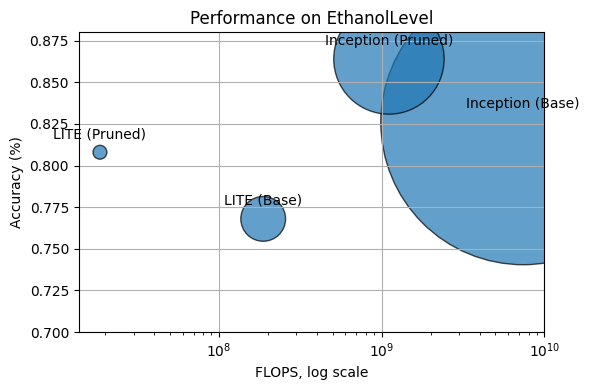

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Provided data
flop_df = pd.DataFrame([
    [0.826000, 1484071588 * 5, 420708],
    [0.864000, 221995706 * 5,  63149],
    [0.768000, 37485672 * 5,   10384],
    [0.808000, 3722642 * 5,    991]
], columns=['acc', 'FLOPS', 'params'])

# Plot with circle sizes based on number of parameters
plt.figure(figsize=(6, 4))
scatter = plt.scatter(flop_df['FLOPS'], flop_df['acc'], s=flop_df['params'] / 10, alpha=0.7, edgecolors='k')

# Annotate points
labels = ['Inception (Base)', 'Inception (Pruned)', 'LITE (Base)', 'LITE (Pruned)']
for i, label in enumerate(labels):
    plt.annotate(label, (flop_df['FLOPS'][i], flop_df['acc'][i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.xscale('log')
plt.xlabel('FLOPS, log scale')
plt.ylabel('Accuracy (%)')
plt.ylim(0.7, 0.88)
plt.title('Performance on EthanolLevel')
plt.grid(True)
plt.tight_layout()
plt.savefig('flops_2.pdf')
plt.show()


In [ ]:
flop_df['flop_ratio'] = flop_df['params'] / 420708
flop_df

,acc,FLOPS,params,flop_ratio
0,0.826,1484071588,420708,1.000000
1,0.864,221995706,63149,0.150102
2,0.768,37485672,10384,0.024682
3,0.808,3722642,991,0.002356


In [ ]:
991 / 9946

0.0996380454454052

In [ ]:
553/10384

0.053255007704160244

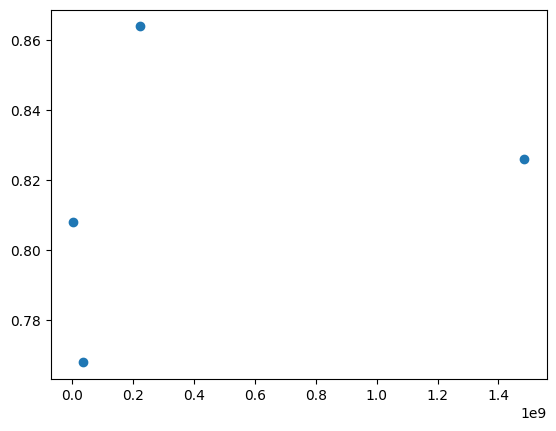

In [ ]:
import matplotlib.pyplot as plt
plt.scatter( flop_df['FLOPS'], flop_df['acc'],)

In [ ]:
tmp_df_inc['flop_ratio_diff'] = (tmp_df_inc['base_flops'] - tmp_df_inc['pruned_flops']) / tmp_df_inc['base_flops']

In [ ]:
tmp_df_inc.sort_values(['flop_ratio_diff'], ascending=False)

,Dataset,base_l_macs,base_l_params,base_l_params_manual,pruned_l_macs,pruned_l_params,pruned_l_params_manual,base_flops,pruned_flops,flop_ratio_diff
0,EthanolLevel,742035794,420708,13902583,110997853,63149,63149,37485672,3722642,0.900692
0,HandOutlines,1148014860,420450,53939116,22498251,8205,8205,57994404,8300384,0.856876
0,SonyAIBORobotSurface2,27545828,420450,42994000,6435363,98171,98171,1391652,207260,0.851069
0,StarLightCurves,433949059,420579,43414579,29350927,28414,28414,21921990,3520554,0.839405
0,FreezerSmallTrain,127557436,420450,17277664,45724960,150458,150458,6443940,1038478,0.838844
...,...,...,...,...,...,...,...,...,...,...
0,UWaveGestureLibraryX,133491102,421224,48464881,45884256,144688,144688,6744048,5365368,0.204429
0,MiddlePhalanxTW,33903014,420966,29489935,11865836,147141,147141,1713036,1507204,0.120156
0,ElectricDevices,40683591,421095,52677766,18043223,186442,186442,2055630,1906624,0.072487
0,MelbournePedestrian,10171962,421482,28227940,4050572,167525,167525,514452,491444,0.044723
